In [1]:
# testing the feature generation from communities
from lfr_generator import generate_features_from_communities
generate_features_from_communities(true_labels=[0, 1, 2, 3, 0, 2, 1, 1, 2, 3], 
                                   mode = 'gaussian', num_features=5, n_clusters_f=5)

array([[ 0.97125674, -0.76460365,  3.03460073,  0.61124548,  0.71385807],
       [-0.02347035, -1.90776535,  1.54931914, -2.94077968, -3.37411828],
       [-2.13268081, -1.18816213, -0.1601611 , -2.95068314, -2.79929842],
       [ 2.07711242, -0.32439875, -0.05932338, -1.26684347, -0.2444996 ],
       [ 0.68870531, -1.24856614, -0.46146476,  3.41166551, -0.9437072 ],
       [-2.32058867, -2.63486623, -0.58625996, -1.43831495, -1.86405897],
       [ 0.08508547,  0.08766473,  1.17408875, -3.52106448, -3.61112272],
       [-2.31081628,  0.29297938,  0.24135883, -3.7242819 , -1.80792898],
       [-1.87211851, -0.91947954,  0.84085373, -2.61057371, -2.52198551],
       [ 3.51154167,  0.40453944,  1.61239653, -2.12955499,  2.42939772]])

In [2]:
import attacks
true_labels = [0, 1, 2, 3, 0, 2, 1, 1, 2, 3]
target_list = [0, 1, 2, 4]
M1 = attacks.compute_M1(target_list=target_list, labels=true_labels)
print("M1 matrix:")
print(M1)

M1 matrix:
0.3333333333333333


In [3]:
import attacks
true_labels = [0, 1, 2, 3, 0, 2, 1, 1, 2, 3]
target_list = [0, 1, 2, 4]
M2 = attacks.compute_M2(target_list=target_list, labels=true_labels)
print("M2 matrix:")
print(M2)

M2 matrix:
0.6666666666666666


## LFR graph generation

In [4]:
from lfr_generator import generate_lfr_graph

num_features = 16
n_f = 13
G, data, true_labels = generate_lfr_graph(mu=0.1, n=1000, num_features=num_features, feature_mode='gaussian', n_clusters_f=n_f)
# G_random, data_random, true_labels = generate_lfr_graph(mu=0.1, n=1000, num_features=num_features, feature_mode='random')
print("Graph generated with the following parameters:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Number of communities: {len(set(true_labels))}")



Graph generated with the following parameters:
Number of nodes: 1000
Number of edges: 17448
Number of communities: 25


In [8]:
import torch
import dmon

def train_model(data, true_labels, num_features):
    """
    Train the DMoN model on the provided data.
    
    Parameters:
    - data: The graph data containing node features and edge indices.
    - true_labels: The ground truth labels for the nodes.
    - num_features: The number of features per node.
    """
    # Initialize the DMoN model
    import dmon
    import torch

    num_clusters = len(set(true_labels))
    model = dmon.DMoN(in_channels=num_features, num_clusters=num_clusters, gcn_skip=True)

    learning_rate = 0.005
    weight_decay = 5e-4
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Train the model
    for epoch in range(201):
        model.train()
        optimizer.zero_grad()
        ca, loss = model(data.x, data.edge_index)
        loss.backward()
        optimizer.step()
        # if epoch % 20 == 0:
        #     print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
    model.eval()
    ca, _ = model(data.x, data.edge_index)
    pred_labels = ca.argmax(dim=1).numpy()

    return pred_labels

In [10]:
from lfr_generator import generate_lfr_graph
import attacks 
import random
import torch
from torch_geometric.utils import from_networkx
from sklearn.metrics import normalized_mutual_info_score


num_features = [16, 32]
num_features =  16
sigma_c = [0.1, 0.5, 1, 2, 5, 10]
sigma_c = [0.1, 1, 5]
mu = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
realizations = 50
n = [1000, 10000]
n = 1000  # Number of nodes in the graph
b = [2, 4, 6, 8, 10]
b = 10  # Budget for the DICE attack
random.seed(42)  # For reproducibility
target_label = 0

for s in sigma_c:
    G, data, true_labels = generate_lfr_graph(mu=0.1, n=n, num_features=num_features, 
                                                feature_mode='gaussian', sigma_c=s)
    print(f"Generated LFR graph with sigma_c={s}.")
    print(f"Training DMON on graph with {G.number_of_nodes()} nodes, {G.number_of_edges()} edges and {num_features} features per node.")
    pred_labels = train_model(data, true_labels, num_features)

    # Compute NMI and element-centric similarity
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    print(f"NMI between DMoN and LFR ground truth: {nmi:.4f}")
    ecs_sim = attacks.compute_ECS(true_labels, pred_labels)
    print(f"ECS between DMoN and LFR ground truth: {ecs_sim:.4f}")
    
    target_community = [n for n, label in enumerate(true_labels) if label == target_label]
    M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
    print(f"M1 after DICE attack: {M1:.4f}")
    M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
    print(f"M2 after DICE attack: {M2:.4f}")

    # Apply DICE attack
    print(f"Target community for DICE attack: {target_label} (size of {len(target_community)})")
    G_attacked = attacks.dice_community_attack(G, target_community, b)
    print(f"    Graph attacked with DICE with budget {b} on target community {target_label}.")

    # Re-train the model on the attacked graph
    data_attacked = from_networkx(G_attacked)
    data_attacked.x = torch.stack([G_attacked.nodes[i]['x'] for i in range(len(G_attacked))])
    print("    Training on attacked graph...")
    pred_labels = train_model(data_attacked, true_labels, num_features)

    # Compute NMI and element-centric similarity
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    print(f"    NMI between DMoN and LFR ground truth: {nmi:.4f}")
    ecs_sim = attacks.compute_ECS(true_labels, pred_labels)
    print(f"    ECS between DMoN and LFR ground truth: {ecs_sim:.4f}")

    M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
    print(f"    M1 after DICE attack: {M1:.4f}")
    M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
    print(f"    M2 after DICE attack: {M2:.4f}")
    print("---------------------------------\n")


Generated LFR graph with sigma_c=0.1.
Training DMON on graph with 1000 nodes, 17448 edges and 16 features per node.
NMI between DMoN and LFR ground truth: 0.8595
ECS between DMoN and LFR ground truth: 0.6381
M1 after DICE attack: 0.0022
M2 after DICE attack: 0.0184
Target community for DICE attack: 0 (size of 20)
    Graph attacked with DICE with budget 10 on target community 0.
    Training on attacked graph...
    NMI between DMoN and LFR ground truth: 0.8693
    ECS between DMoN and LFR ground truth: 0.6692
    M1 after DICE attack: 0.0208
    M2 after DICE attack: 0.1735
---------------------------------

Generated LFR graph with sigma_c=1.
Training DMON on graph with 1000 nodes, 17448 edges and 16 features per node.
NMI between DMoN and LFR ground truth: 0.9549
ECS between DMoN and LFR ground truth: 0.8536
M1 after DICE attack: 0.0000
M2 after DICE attack: 0.0143
Target community for DICE attack: 0 (size of 20)
    Graph attacked with DICE with budget 10 on target community 0.
   

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

from lfr_generator import generate_lfr_graph
import attacks
import random
import torch
from torch_geometric.utils import from_networkx
from sklearn.metrics import normalized_mutual_info_score

num_features = 16
sigma_c_values = [0.1, 1, 5]
# mu_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
mu_values = [0.01, 0.1, 0.3,  0.5]
realizations = 10
n = 1000
b_values = [2, 4, 6, 8, 10]
target_label = 0
random.seed(42)  # For reproducibility

results = {}  # {mu: {sigma_c: {b: {"nmi": [], "ecs": [], "M1": [], "M2": []}}}}

for mu in tqdm(mu_values, desc="mu values"):
    results[mu] = {}
    for sigma_c in sigma_c_values:
        print(f"Generating graphs for mu={mu}, sigma_c={sigma_c}")
        results[mu][sigma_c] = {bb: {"nmi": [], "ecs": [], "M1": [], "M2": []} for bb in b_values}
        results[mu][sigma_c][0] = {"nmi": [], "ecs": [], "M1": [], "M2": []}
        for realization in tqdm(range(realizations), desc=f"sigma_c={sigma_c}"):
            print(f"Realization {realization + 1}/{realizations}")
            G, data, true_labels = generate_lfr_graph(
                mu=mu, n=n, num_features=num_features, 
                feature_mode='gaussian', sigma_c=sigma_c
            )
            pred_labels = train_model(data, true_labels, num_features)
            target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
            nmi = normalized_mutual_info_score(true_labels, pred_labels)
            ecs = attacks.compute_ECS(true_labels, pred_labels)
            M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
            M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
            # Store results for the original graph
            results[mu][sigma_c][0]["nmi"].append(nmi)
            results[mu][sigma_c][0]["ecs"].append(ecs)
            results[mu][sigma_c][0]["M1"].append(M1)
            results[mu][sigma_c][0]["M2"].append(M2)
            for bb in b_values:
                print(f"Applying DICE attack with budget {bb} on target community {target_label}")
                G_attacked = attacks.dice_community_attack(G.copy(), target_community, bb)
                data_attacked = from_networkx(G_attacked)
                data_attacked.x = torch.stack([G_attacked.nodes[i]['x'] for i in range(len(G_attacked))])
                pred_labels_attacked = train_model(data_attacked, true_labels, num_features)

                nmi = normalized_mutual_info_score(true_labels, pred_labels_attacked)
                ecs = attacks.compute_ECS(true_labels, pred_labels_attacked)
                M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked)
                M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked)

                results[mu][sigma_c][bb]["nmi"].append(nmi)
                results[mu][sigma_c][bb]["ecs"].append(ecs)
                results[mu][sigma_c][bb]["M1"].append(M1)
                results[mu][sigma_c][bb]["M2"].append(M2)


mu values:   0%|          | 0/4 [00:00<?, ?it/s]

Generating graphs for mu=0.01, sigma_c=0.1


Realization 1/10
Applying DICE attack with budget 2 on target community 0
Applying DICE attack with budget 4 on target community 0
Applying DICE attack with budget 6 on target community 0
Applying DICE attack with budget 8 on target community 0
Applying DICE attack with budget 10 on target community 0


Realization 2/10
Applying DICE attack with budget 2 on target community 0
Applying DICE attack with budget 4 on target community 0
Applying DICE attack with budget 6 on target community 0
Applying DICE attack with budget 8 on target community 0
Applying DICE attack with budget 10 on target community 0


Realization 3/10
Applying DICE attack with budget 2 on target community 0
Applying DICE attack with budget 4 on target community 0
Applying DICE attack with budget 6 on target community 0
Applying DICE attack with budget 8 on target community 0
Applying DICE attack with budget 10 on target community 0


...

Realization 7/10
Applying DICE attack with budget 2 on target community 0
Applying DICE attack with budget 4 on target community 0
Applying DICE attack with budget 6 on target community 0
Applying DICE attack with budget 8 on target community 0
Applying DICE attack with budget 10 on target community 0


Realization 8/10
Applying DICE attack with budget 2 on target community 0
Applying DICE attack with budget 4 on target community 0
Applying DICE attack with budget 6 on target community 0
Applying DICE attack with budget 8 on target community 0
Applying DICE attack with budget 10 on target community 0


Realization 9/10
Applying DICE attack with budget 2 on target community 0
Applying DICE attack with budget 4 on target community 0
Applying DICE attack with budget 6 on target community 0
Applying DICE attack with budget 8 on target community 0
Applying DICE attack with budget 10 on target community 0


Realization 10/10
Applying DICE attack with budget 2 on target community 0
Applying DICE attack with budget 4 on target community 0
Applying DICE attack with budget 6 on target community 0
Applying DICE attack with budget 8 on target community 0
Applying DICE attack with budget 10 on target community 0


mu values: 100%|██████████| 4/4 [1:05:35<00:00, 983.91s/it]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

from lfr_generator import generate_lfr_graph
import attacks
import random
import torch
from torch_geometric.utils import from_networkx
from sklearn.metrics import normalized_mutual_info_score

num_features = 16
sigma_c_values = [0.1, 1, 5]
# mu_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
mu_values = [0.01, 0.1, 0.3,  0.5]
realizations = 10
n = 1000
b_values = [2, 4, 6, 8, 10]
target_label = 0
random.seed(42)  # For reproducibility

results = {}  # {mu: {sigma_c: {b: {"nmi": [], "ecs": [], "M1": [], "M2": []}}}}

for mu in tqdm(mu_values, desc="mu values"):
    results[mu] = {}
    for sigma_c in sigma_c_values:
        print(f"Generating graphs for mu={mu}, sigma_c={sigma_c}")
        results[mu][sigma_c] = {bb: {"nmi": [], "ecs": [], "M1": [], "M2": []} for bb in b_values}
        results[mu][sigma_c][0] = {"nmi": [], "ecs": [], "M1": [], "M2": []}
        for realization in tqdm(range(realizations), desc=f"sigma_c={sigma_c}"):
            print(f"Realization {realization + 1}/{realizations}")
            G, data, true_labels = generate_lfr_graph(
                mu=mu, n=n, num_features=num_features, 
                feature_mode='gaussian', sigma_c=sigma_c
            )
            pred_labels = train_model(data, true_labels, num_features)
            target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
            nmi = normalized_mutual_info_score(true_labels, pred_labels)
            ecs = attacks.compute_ECS(true_labels, pred_labels)
            M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
            M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
            # Store results for the original graph
            results[mu][sigma_c][0]["nmi"].append(nmi)
            results[mu][sigma_c][0]["ecs"].append(ecs)
            results[mu][sigma_c][0]["M1"].append(M1)
            results[mu][sigma_c][0]["M2"].append(M2)
            for bb in b_values:
                print(f"Applying DICE attack with budget {bb} on target community {target_label}")
                G_attacked = attacks.dice_community_attack(G.copy(), target_community, bb)
                data_attacked = from_networkx(G_attacked)
                data_attacked.x = torch.stack([G_attacked.nodes[i]['x'] for i in range(len(G_attacked))])
                pred_labels_attacked = train_model(data_attacked, true_labels, num_features)

                nmi = normalized_mutual_info_score(true_labels, pred_labels_attacked)
                ecs = attacks.compute_ECS(true_labels, pred_labels_attacked)
                M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked)
                M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked)

                results[mu][sigma_c][bb]["nmi"].append(nmi)
                results[mu][sigma_c][bb]["ecs"].append(ecs)
                results[mu][sigma_c][bb]["M1"].append(M1)
                results[mu][sigma_c][bb]["M2"].append(M2)


In [18]:
import pickle

with open('dmon_attack_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("Results saved to dmon_attack_results.pkl")


Results saved to dmon_attack_results.pkl


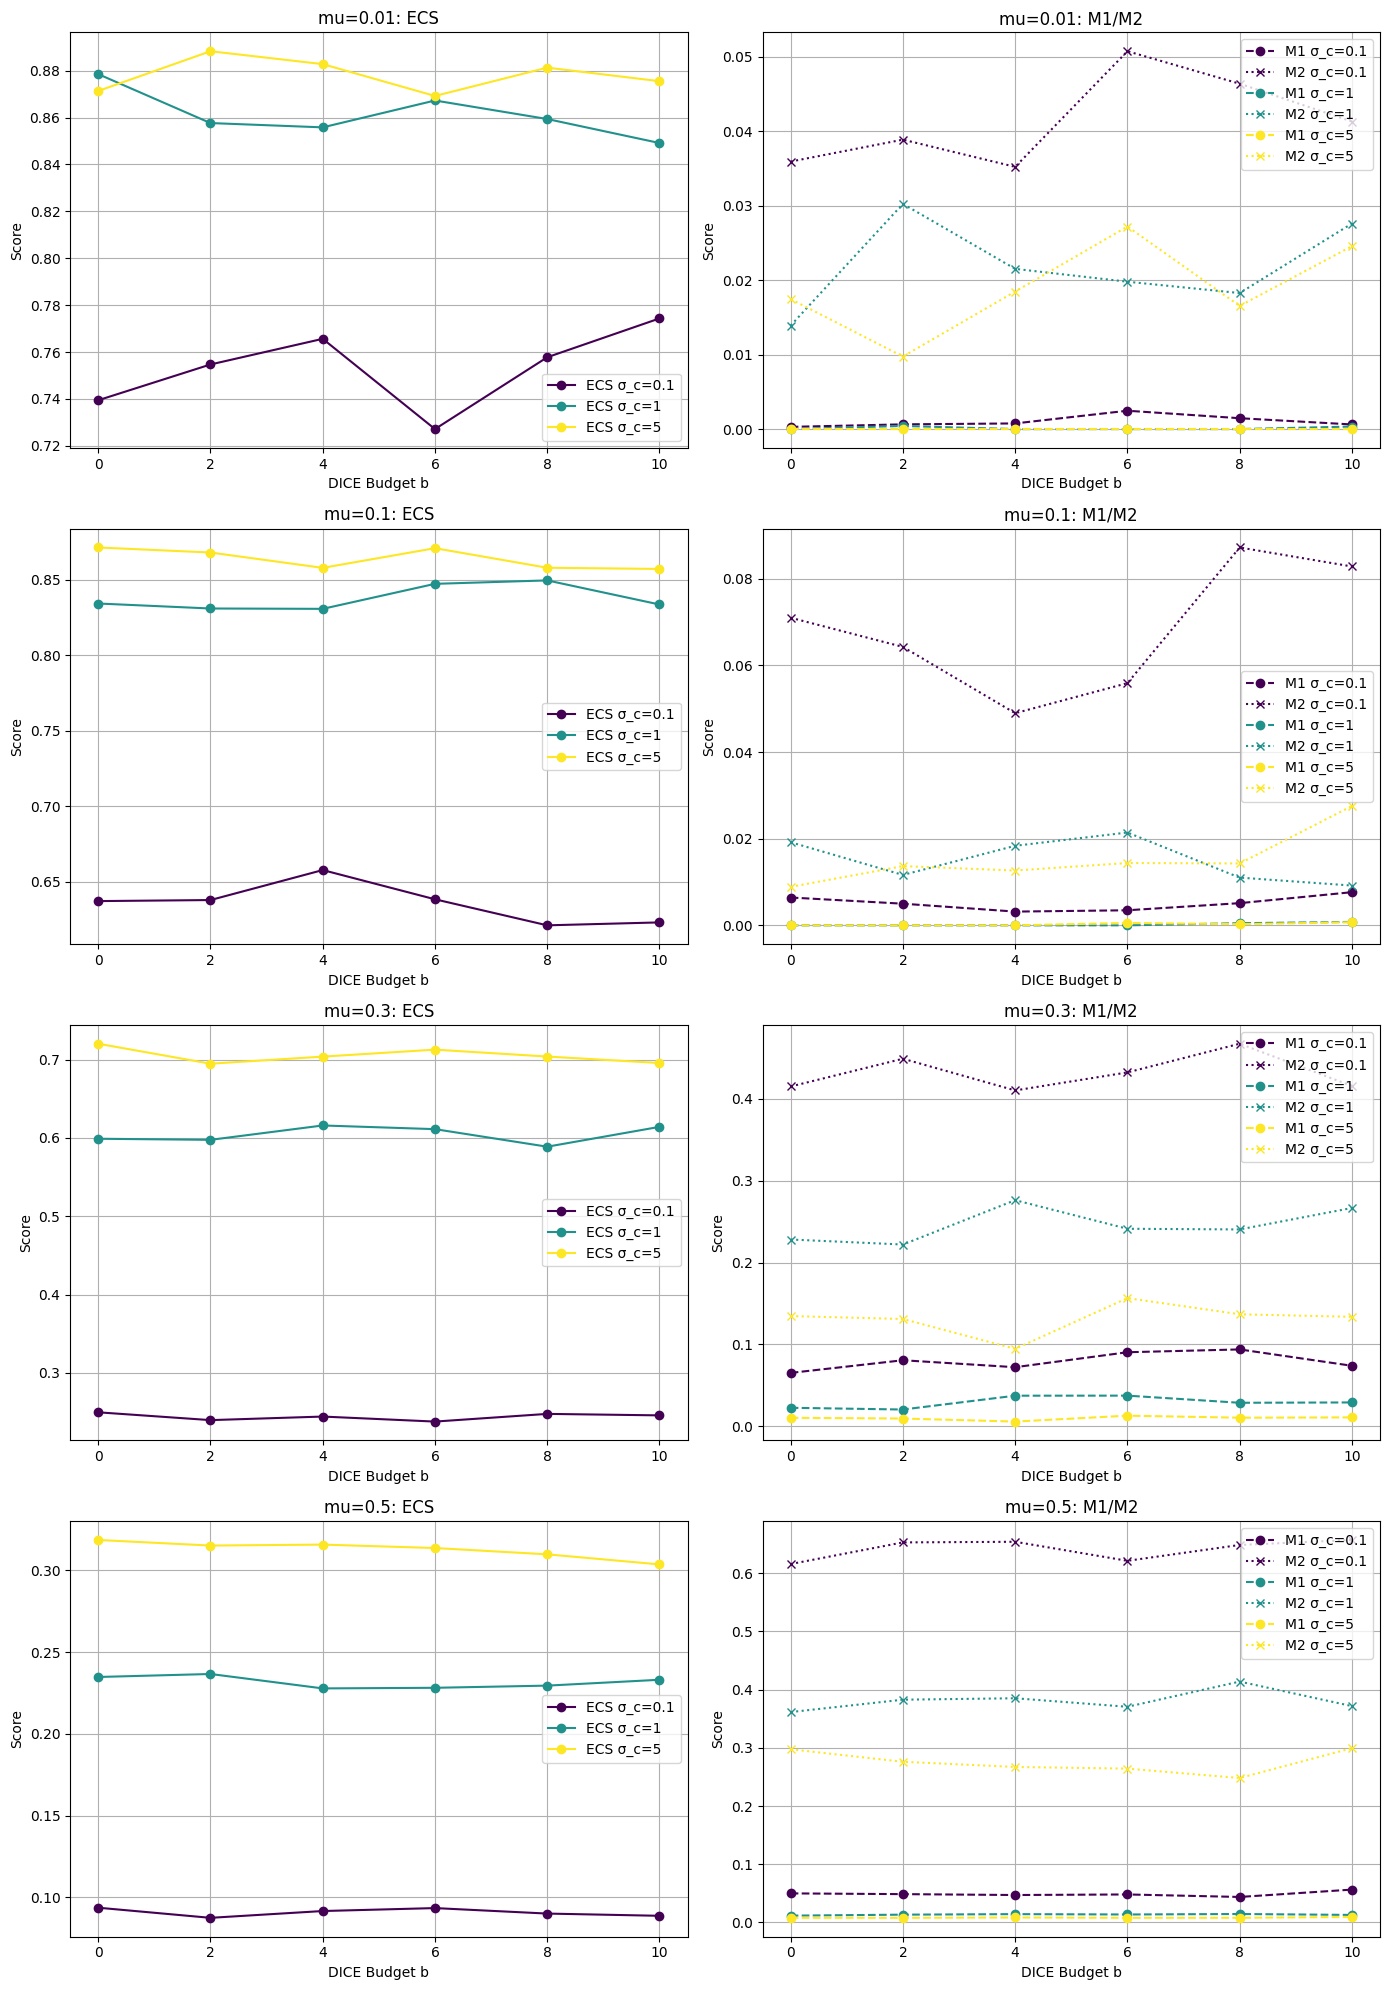

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

# Define colors for each sigma_c value, so colors are consistent across subplots
color_map = {s: c for s, c in zip(sigma_c_values, plt.cm.viridis(np.linspace(0, 1, len(sigma_c_values))))}

metric_styles = {
    'nmi': 'dotted',
    'ecs': 'solid',
    'M1': 'dashed',
    'M2': 'dotted'
}
metric_markers = {
    'nmi': 'x',
    'ecs': 'o',
    'M1': 'o',
    'M2': 'x'
}

fig, axes = plt.subplots(len(mu_values), 2, figsize=(14, 5 * len(mu_values)))

for idx, mu in enumerate(mu_values):
    for sigma_c in sigma_c_values:
        color = color_map[sigma_c]
        # Column 1: NMI/ECS
        # nmi_means = [np.mean(results[mu][sigma_c][bb]["nmi"]) for bb in [0] + b_values]
        ecs_means = [np.mean(results[mu][sigma_c][bb]["ecs"]) for bb in [0] + b_values]
        # axes[idx, 0].plot([0] + b_values, nmi_means, marker=metric_markers['nmi'], linestyle=metric_styles['nmi'],
        #                   color=color, label=f'NMI σ_c={sigma_c}')
        axes[idx, 0].plot([0] + b_values, ecs_means, marker=metric_markers['ecs'], linestyle=metric_styles['ecs'],
                          color=color, label=f'ECS σ_c={sigma_c}')

        # Column 2: M1/M2
        M1_means = [np.mean(results[mu][sigma_c][bb]["M1"]) for bb in [0] + b_values]
        M2_means = [np.mean(results[mu][sigma_c][bb]["M2"]) for bb in [0] + b_values]

        axes[idx, 1].plot([0] + b_values, M1_means, marker=metric_markers['M1'], linestyle=metric_styles['M1'],
                          color=color, label=f'M1 σ_c={sigma_c}')
        axes[idx, 1].plot([0] + b_values, M2_means, marker=metric_markers['M2'], linestyle=metric_styles['M2'],
                          color=color, label=f'M2 σ_c={sigma_c}')


    axes[idx, 0].set_title(f"mu={mu}: ECS")
    axes[idx, 1].set_title(f"mu={mu}: M1/M2")
    for ax in axes[idx]:
        ax.set_xlabel("DICE Budget b")
        ax.set_ylabel("Score")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()



### Random features

In [ ]:
G_random, data_random, true_labels = generate_lfr_graph(mu=0.1, n=1000, num_features=num_features, feature_mode='random')
print("Graph generated with the following parameters:")
print(f"Number of nodes: {G_random.number_of_nodes()}")
print(f"Number of edges: {G_random.number_of_edges()}")
print(f"Number of communities: {len(set(true_labels))}")

Graph generated with the following parameters:
Number of nodes: 1000
Number of edges: 18114
Number of communities: 13


In [ ]:
import torch
import dmon

num_clusters = len(set(true_labels))
model = dmon.DMoN(in_channels=num_features, num_clusters=num_clusters, gcn_skip=True)

learning_rate = 0.005
weight_decay = 5e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Train the model
for epoch in range(201):
    model.train()
    optimizer.zero_grad()
    ca, loss = model(data_random.x, data_random.edge_index)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

Epoch 000 | Loss: 1.2026
Epoch 020 | Loss: 0.3920
Epoch 040 | Loss: 0.0732
Epoch 060 | Loss: 0.0716
Epoch 080 | Loss: 0.0286
Epoch 100 | Loss: 0.0018
Epoch 120 | Loss: 0.0427
Epoch 140 | Loss: 0.0163
Epoch 160 | Loss: -0.0056
Epoch 180 | Loss: -0.0168
Epoch 200 | Loss: -0.0279


In [ ]:
model.eval()
ca, _ = model(data_random.x, data_random.edge_index)
pred_labels = ca.argmax(dim=1).numpy()

# print(f"Shape of predicted labels: {pred_labels.shape}")

In [ ]:
from sklearn.metrics import normalized_mutual_info_score
from clusim.clustering import Clustering
from clusim.sim import element_sim # Element-centric similarity from A.J. Gates and YY Ahn

nmi = normalized_mutual_info_score(true_labels, pred_labels)
print(f"NMI between DMoN and LFR ground truth: {nmi:.4f}")


# Convert label lists to CluSim Clustering objects
true_clustering = Clustering().from_membership_list(true_labels)
pred_clustering = Clustering().from_membership_list(pred_labels)

# Compute element-centric similarity
ecs_sim = element_sim(true_clustering, pred_clustering)
print(f"ECS between DMoN and LFR ground truth: {ecs_sim:.4f}")


NMI between DMoN and LFR ground truth: 0.4929
ECS between DMoN and LFR ground truth: 0.3502
